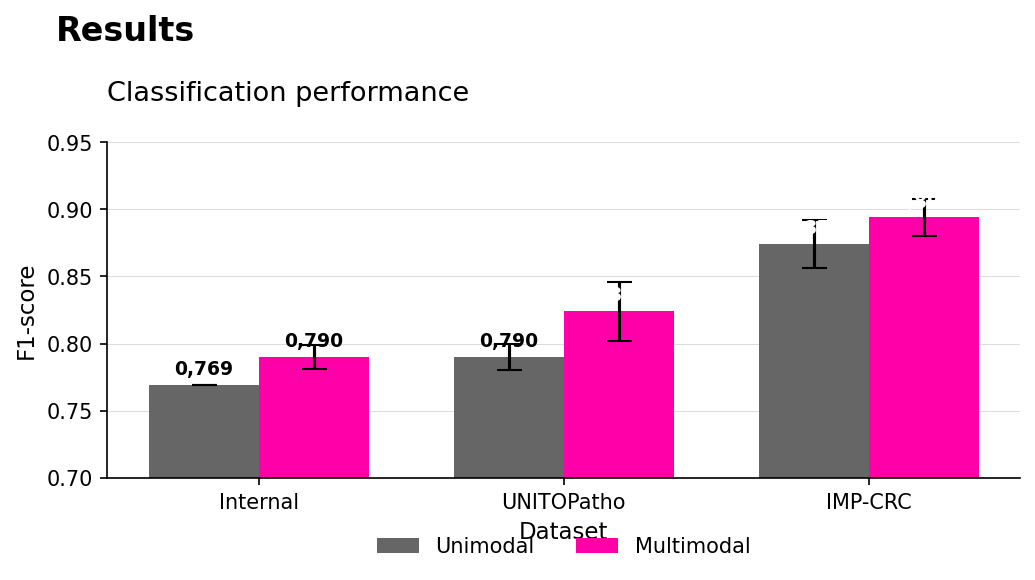

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) Datos
# ------------------------------------------------------------------
datasets = ["Internal", "UNITOPatho", "IMP-CRC"]

# Medias
unimodal =     [0.769, 0.790, 0.874]
multimodal =   [0.790, 0.824, 0.894]

# Desviaciones estándar (cámbialas si actualizas la tabla)
sd_unimodal =  [0.000, 0.010, 0.018]
sd_multimodal =[0.009, 0.022, 0.014]

x = np.arange(len(datasets))
width = 0.36  # ancho de cada barra

# ------------------------------------------------------------------
# 2) Estilo general (tipo Google Slides)
# ------------------------------------------------------------------
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Google Sans",       # si la tienes instalada
    "IBM Plex Sans",     # alternativa
    "Inter",
    "DejaVu Sans"        # fallback
]

fig, ax = plt.subplots(figsize=(7, 4))

# Colores tipo Google: gris para unimodal, magenta para multimodal
color_uni = "#666666"
color_multi = "#ff00a8"

# ------------------------------------------------------------------
# 3) Barras con barras de error (SD)
# ------------------------------------------------------------------
bars_uni = ax.bar(
    x - width/2, unimodal, width,
    label="Unimodal",
    yerr=sd_unimodal,
    capsize=6,
    color=color_uni
)

bars_multi = ax.bar(
    x + width/2, multimodal, width,
    label="Multimodal",
    yerr=sd_multimodal,
    capsize=6,
    color=color_multi
)

# ------------------------------------------------------------------
# 4) Ejes, rejilla y títulos
# ------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(datasets)

ax.set_ylabel("F1-score", fontsize=11)
ax.set_xlabel("Dataset", fontsize=11)

# Títulos en dos niveles, rollo “Results / Classification performance”
fig.suptitle("Results", x=0.06, ha="left",
             fontsize=16, fontweight="bold")
ax.set_title("Classification performance",
             fontsize=13, loc="left", pad=20)

# Límite del eje Y para que quede centrado visualmente
ax.set_ylim(0.70, 0.95)

# Rejilla horizontal suave (tipo Google)
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, color="#dddddd")
ax.set_axisbelow(True)

# Quitar bordes superior y derecho
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Leyenda simple debajo
legend = ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

# ------------------------------------------------------------------
# 5) Etiquetas numéricas encima de cada barra
# ------------------------------------------------------------------
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}".replace(".", ","),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # desplazamiento en puntos
                    textcoords="offset points",
                    ha="center", va="bottom",
                    fontsize=9, color="white" if height > 0.8 else "black",
                    fontweight="semibold")

autolabel(bars_uni)
autolabel(bars_multi)

plt.tight_layout()
plt.show()
# Si quieres guardarlo para pegarlo en las slides:


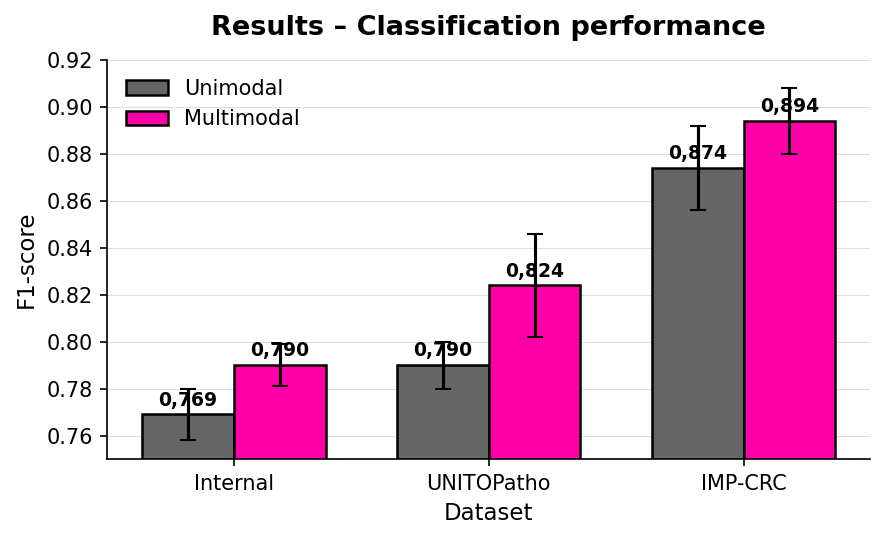

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ 1) Datos ------------------
datasets = ["Internal", "UNITOPatho", "IMP-CRC"]

unimodal      = [0.769, 0.790, 0.874]
multimodal    = [0.790, 0.824, 0.894]

sd_unimodal   = [0.011, 0.010, 0.018]
sd_multimodal = [0.009, 0.022, 0.014]

x = np.arange(len(datasets))
width = 0.36

# ------------------ 2) Estilo global ------------------
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Inter", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(6, 3.7))
fig.patch.set_facecolor("white")

color_uni   = "#666666"
color_multi = "#ff00a8"

# ------------------ 3) Barras + SD ------------------
bars_uni = ax.bar(
    x - width/2, unimodal, width,
    yerr=sd_unimodal,
    capsize=4,
    linewidth=1.2,
    edgecolor="black",
    color=color_uni,
    label="Unimodal"
)

bars_multi = ax.bar(
    x + width/2, multimodal, width,
    yerr=sd_multimodal,
    capsize=4,
    linewidth=1.2,
    edgecolor="black",
    color=color_multi,
    label="Multimodal"
)

# ------------------ 4) Ejes, títulos, rejilla ------------------
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=10)

ax.set_ylabel("F1-score", fontsize=11)
ax.set_xlabel("Dataset", fontsize=11)

ax.set_title("Results – Classification performance",
             fontsize=13, fontweight="bold", pad=12)

# rango ajustado para que quede compacto
ax.set_ylim(0.75, 0.92)

ax.yaxis.grid(True, linestyle="-", linewidth=0.5, color="#dddddd")
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, fontsize=10, loc="upper left")

# ------------------ 5) Etiquetas numéricas ------------------
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,  # un poco por encima
            f"{height:.3f}".replace(".", ","),
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

add_value_labels(bars_uni)
add_value_labels(bars_multi)

plt.tight_layout()
plt.show()
# Si quieres guardarlo:
# fig.savefig("medical_results_f1_clean.png", dpi=300, bbox_inches="tight")
